In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("taxis")

df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
print("Missing values before cleaning:")
print(df.isnull().sum())

for col in ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in ['payment', 'pickup_borough', 'dropoff_borough', 'pickup_zone', 'dropoff_zone']:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

df.dropna(subset=['fare', 'distance'], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Missing values after cleaning:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [4]:
df['pickup'] = pd.to_datetime(df['pickup'])

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

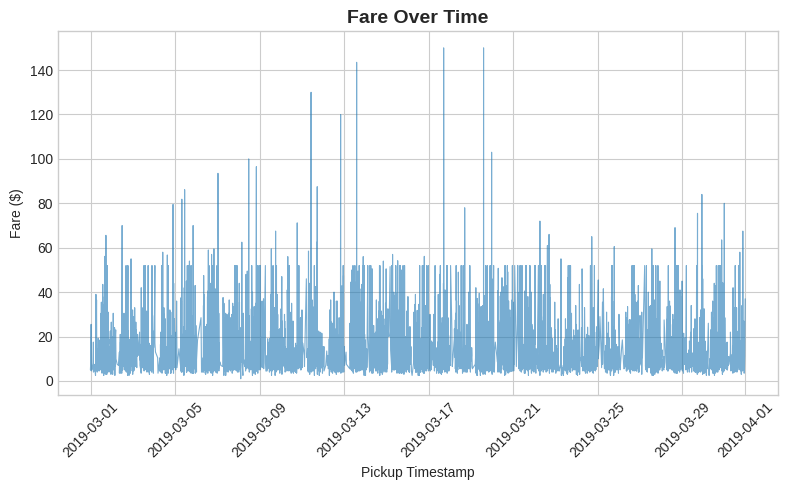

In [6]:
plt.figure(figsize=(8, 5))
df_sorted = df.sort_values('pickup')
plt.plot(df_sorted['pickup'], df_sorted['fare'], color='tab:blue', alpha=0.6, linewidth=0.8)
plt.title("Fare Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Pickup Timestamp")
plt.ylabel("Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

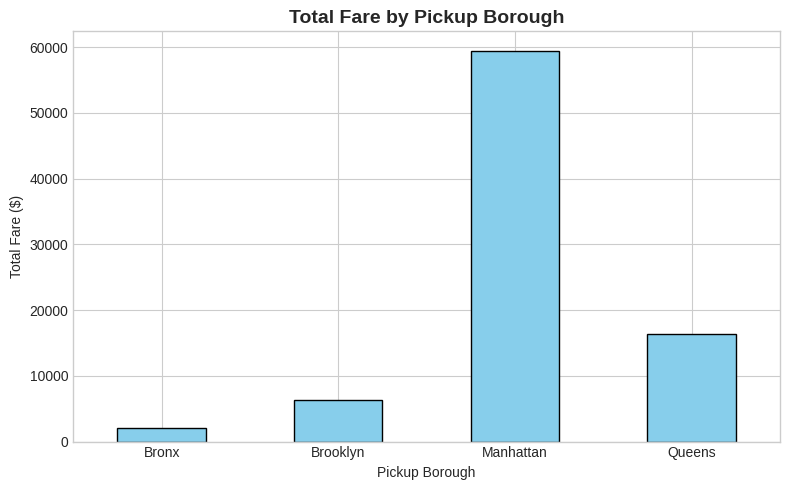

In [7]:
plt.figure(figsize=(8, 5))
fare_by_borough = df.groupby('pickup_borough')['fare'].sum()
fare_by_borough.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Total Fare by Pickup Borough", fontsize=14, fontweight='bold')
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

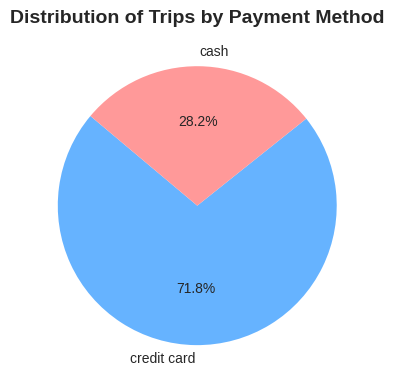

In [9]:
plt.figure(figsize=(4, 4))
payment_counts = df['payment'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title("Distribution of Trips by Payment Method", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

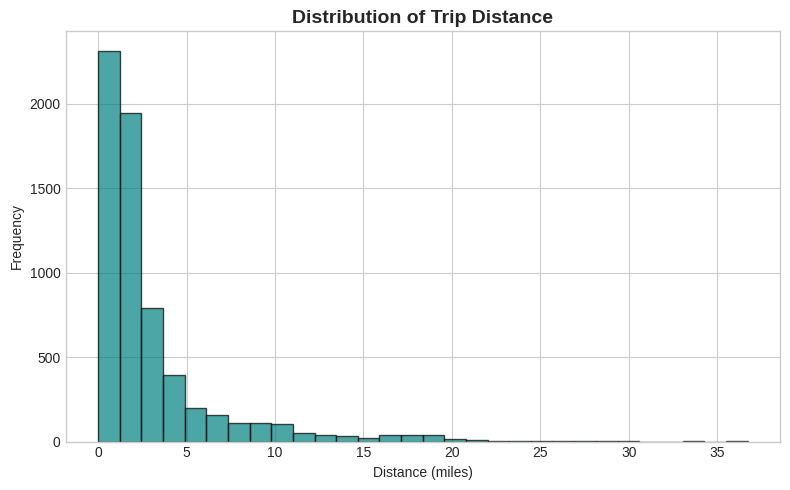

In [10]:
plt.figure(figsize=(8, 5))
df['distance'].plot(kind='hist', bins=30, color='teal', edgecolor='black', alpha=0.7)
plt.title("Distribution of Trip Distance", fontsize=14, fontweight='bold')
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [11]:
sns.set_theme(style="whitegrid")

/tmp/ipykernel_1570/1773528816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_borough', palette='viridis')


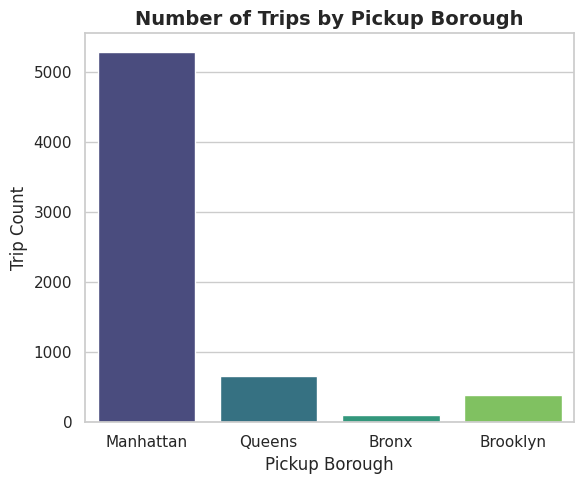

In [13]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='pickup_borough', palette='viridis')
plt.title("Number of Trips by Pickup Borough", fontsize=14, fontweight='bold')
plt.xlabel("Pickup Borough")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

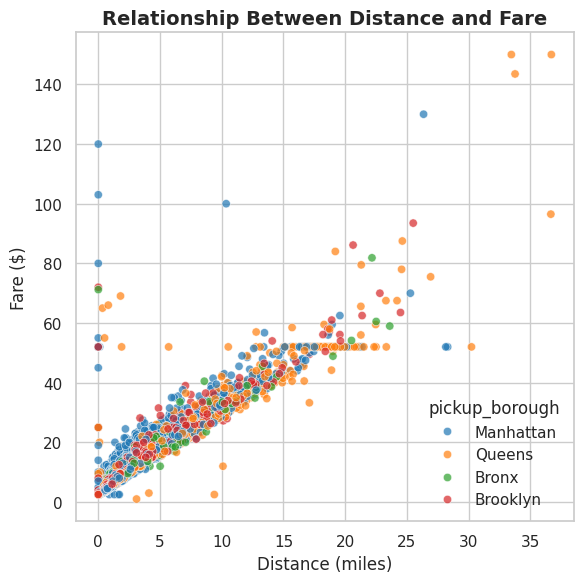

In [15]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough', alpha=0.7, palette='tab10')
plt.title("Relationship Between Distance and Fare", fontsize=14, fontweight='bold')
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1570/4046893420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='payment', y='fare', palette='muted', inner='quartile')


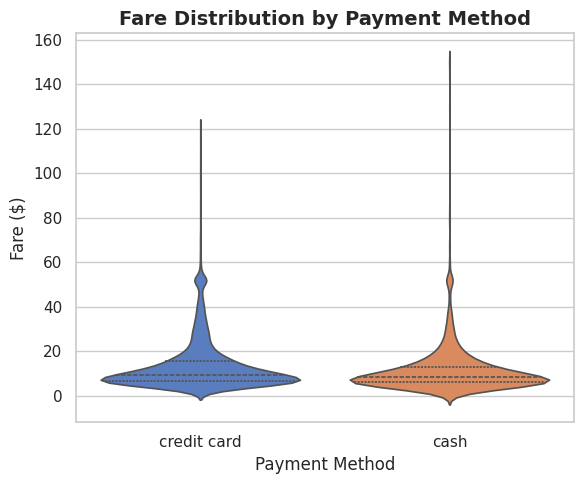

In [24]:
plt.figure(figsize=(6, 5))
sns.violinplot(data=df, x='payment', y='fare', palette='muted', inner='quartile')
plt.title("Fare Distribution by Payment Method", fontsize=14, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()